In [18]:
def function3(input3):
    return input3

In [19]:
def function1(input):
    return input + " Hello from function1"

def function2(input):
    output = function3("This is function 2 in between")
    return input + " " + output + " and from function2"

In [20]:
from langgraph.graph import Graph

In [21]:
workflow1 = Graph()

In [22]:
workflow1.add_node("function1", function1)

In [23]:
workflow1.add_node("function2", function2)

In [24]:
workflow1.add_edge("function1", "function2")

In [25]:
workflow1.set_entry_point("function1")

In [26]:
workflow1.set_finish_point("function2")

In [27]:
app1 = workflow1.compile()

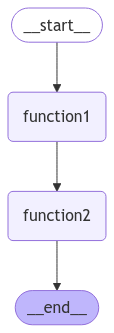

In [29]:
from IPython.display import Image, display

try:
    display(Image(app1.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [30]:
app1.invoke("Hi this is Hitesh")

'Hi this is Hitesh Hello from function1 This is function 2 in between and from function2'

In [31]:
input = "Hi this hitesh"
for output in app1.stream(input):
    for key, value in output.items():
        print(f"here is output from: {key}")
        print("_________")
        print(value)
        print("\n")

here is output from: function1
_________
Hi this hitesh Hello from function1


here is output from: function2
_________
Hi this hitesh Hello from function1 This is function 2 in between and from function2




### **Workflow with LLM**

In [33]:
import os
from dotenv import load_dotenv, find_dotenv 
_ = load_dotenv(find_dotenv())
openai_api_key = os.environ["OPENAI_API_KEY"]

In [35]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings 
embeddings = OpenAIEmbeddings() 
llm = ChatOpenAI()

In [37]:
def function1(input):
    llm = ChatOpenAI() 
    response = llm.invoke(input).content 
    return response

In [38]:
def function2(input):
    upper_case = input.upper() 
    return upper_case

In [39]:
from langgraph.graph import Graph 
workflow2 = Graph()

In [40]:
workflow2.add_node("llm", function1)

In [41]:
workflow2.add_node("Upper_string", function2) 

In [42]:
workflow2.add_edge("llm", "Upper_string")

In [43]:
workflow2.set_entry_point("llm")
workflow2.set_finish_point("Upper_string")

In [44]:
app2 = workflow2.compile()

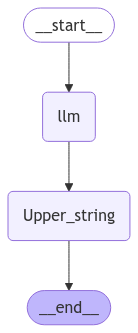

In [45]:
from IPython.display import Image, display

try:
    display(Image(app2.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [47]:
print(app2.invoke("What is GPU ?"))

GPU STANDS FOR GRAPHICS PROCESSING UNIT. IT IS A SPECIALIZED ELECTRONIC CIRCUIT DESIGNED TO RAPIDLY MANIPULATE AND ALTER MEMORY TO ACCELERATE THE CREATION OF IMAGES IN A FRAME BUFFER INTENDED FOR OUTPUT TO A DISPLAY DEVICE. GPUS ARE COMMONLY USED IN GAMING DEVICES, VIDEO EDITING SOFTWARE, AND OTHER APPLICATIONS THAT REQUIRE COMPLEX GRAPHICS PROCESSING.


In [48]:
input = "What is Graphic card, Explain properly"
for output in app2.stream(input):
    for key, value in output.items():
        print(f"here is output from: {key}")
        print("_________")
        print(value)
        print("\n")

here is output from: llm
_________
A graphics card, also known as a video card or GPU (graphics processing unit), is a specialized electronic circuit that accelerates the creation and rendering of images, videos, and animations on a computer screen. It is responsible for processing and displaying visual information on the monitor, and is essential for gaming, video editing, graphic design, and other visually-intensive tasks.

The graphics card is responsible for rendering 2D and 3D images by converting data into signals that the monitor can display. It contains its own processor, memory, and cooling system to handle the complex calculations required for rendering high-quality graphics. The GPU on the graphics card works in conjunction with the CPU (central processing unit) to deliver smooth and realistic visuals on the screen.

Graphics cards come in various models and specifications, with higher-end cards offering better performance and more advanced features such as ray tracing, VR (

### **Token Counter**

In [49]:
def function3(input):
    token = input.split()
    token_number = len(token)
    token_number = f"Total token number is {token_number}"
    return token_number

In [53]:
workflow3 = Graph() 
workflow3.add_node("llm", function1) 
workflow3.add_node("token_counter", function3)
workflow3.add_edge("llm", "token_counter")
workflow3.set_entry_point("llm")
workflow3.set_finish_point("token_counter")
app3 = workflow3.compile()

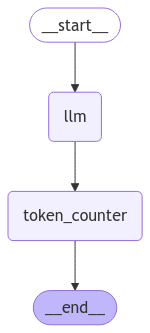

In [54]:
from IPython.display import Image, display

try:
    display(Image(app3.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [55]:
app3.invoke("Why we use GPU in deep learning ?")

'Total token number is 129'